In [ ]:
from dotenv import load_dotenv
load_dotenv()
import os
from langchain_openai import ChatOpenAI

from typing_extensions import TypedDict

from langgraph.graph import StateGraph, START, END

## Reducers
from typing import Annotated
from langgraph.graph.message import add_messages
from langchain_groq import ChatGroq

llm=ChatGroq(model="llama-3.3-70b-versatile")
result=llm.invoke("Hello")
result


d:\Life\ML Hands-on\Github\AI-Agents-Langgraph-Concept\.venv\Lib\site-packages\langgraph\checkpoint\base\__init__.py:18: LangChainPendingDeprecationWarning: The default value of `allowed_objects` will change in a future version. Pass an explicit value (e.g., allowed_objects='messages' or allowed_objects='core') to suppress this warning.
  from langgraph.checkpoint.serde.jsonplus import JsonPlusSerializer


AIMessage(content='Hello. How can I help you today?', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 10, 'prompt_tokens': 36, 'total_tokens': 46, 'completion_time': 0.034120731, 'prompt_time': 0.001715087, 'queue_time': 0.071319866, 'total_time': 0.035835818}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_0761e44d7b', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019ee240-7a5e-7ba3-8442-f5d600841b1a-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 36, 'output_tokens': 10, 'total_tokens': 46})

Failed to multipart ingest runs: langsmith.utils.LangSmithError: Failed to POST https://api.smith.langchain.com/runs/multipart in LangSmith API. HTTPError('403 Client Error: Forbidden for url: https://api.smith.langchain.com/runs/multipart', '{"error":"Forbidden"}\n')
Failed to send compressed multipart ingest: langsmith.utils.LangSmithError: Failed to POST https://api.smith.langchain.com/runs/multipart in LangSmith API. HTTPError('403 Client Error: Forbidden for url: https://api.smith.langchain.com/runs/multipart', '{"error":"Forbidden"}\n')
Failed to send compressed multipart ingest: langsmith.utils.LangSmithError: Failed to POST https://api.smith.langchain.com/runs/multipart in LangSmith API. HTTPError('403 Client Error: Forbidden for url: https://api.smith.langchain.com/runs/multipart', '{"error":"Forbidden"}\n')
Failed to send compressed multipart ingest: langsmith.utils.LangSmithError: Failed to POST https://api.smith.langchain.com/runs/multipart in LangSmith API. HTTPError('403 

### We Will start With Creating Nodes

In [2]:
class State(TypedDict):
    messages:Annotated[list,add_messages]

In [3]:
from langgraph.checkpoint.memory import MemorySaver
memory=MemorySaver()
def superbot(state:State):
    return {"messages":[llm.invoke(state['messages'])]}

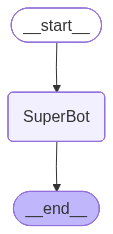

In [4]:
graph=StateGraph(State)

## node
graph.add_node("SuperBot",superbot)
## Edges

graph.add_edge(START,"SuperBot")
graph.add_edge("SuperBot",END)


graph_builder=graph.compile(checkpointer=memory)


## Display
from IPython.display import Image, display
display(Image(graph_builder.get_graph().draw_mermaid_png()))

In [5]:
## Invocation

config = {"configurable": {"thread_id": "1"}}

graph_builder.invoke({'messages':"Hi,My name is Krish And I like cricket"},config)

{'messages': [HumanMessage(content='Hi,My name is Krish And I like cricket', additional_kwargs={}, response_metadata={}, id='6f1d1d96-67a1-45f4-8d3d-988699e0796d'),
  AIMessage(content='Nice to meet you, Krish. Cricket is an exciting sport, and there are many passionate fans around the world. Are you a fan of a particular team or player, or do you enjoy playing the game yourself?', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 44, 'prompt_tokens': 45, 'total_tokens': 89, 'completion_time': 0.145463782, 'prompt_time': 0.004217607, 'queue_time': 0.106265954, 'total_time': 0.149681389}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_0761e44d7b', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019ee240-8882-73b2-a869-ebf8fe66d7d8-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 45, 'output_tokens': 44, 'total_tokens': 89})]}

### Streaming 
Methods: .stream() and astream()

- These methods are sync and async methods for streaming back results.

Additional parameters in streaming modes for graph state

- **values** : This streams the full state of the graph after each node is called.
- **updates** : This streams updates to the state of the graph after each node is called.


#### Streaming The Responses With Stream Method

In [11]:
# Create a thread
config = {"configurable": {"thread_id": "3"}}

for chunk in graph_builder.stream({'messages':"Hi,My name is Krish And I like cricket"},
                                  config,stream_mode="updates"):
    print(chunk)

{'SuperBot': {'messages': [AIMessage(content="Hi Krish, nice to meet you again. We've already had a few conversations about your love for cricket, and I'm excited to chat with you more about it.\n\nSo, what is it about cricket that you enjoy the most? Is it the thrill of hitting a six, the strategy of bowling, or the teamwork involved in playing with your friends or a club?\n\nLet's talk more about cricket, and I can share some fun facts or trivia with you if you'd like!", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 98, 'prompt_tokens': 563, 'total_tokens': 661, 'completion_time': 0.26829317, 'prompt_time': 0.029279726, 'queue_time': 0.14404436, 'total_time': 0.297572896}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_ce7bc1685b', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019ee240-c587-7441-a26f-905a8cd8a09a-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 563, 'ou

In [12]:
for chunk in graph_builder.stream({'messages':"I also like football"},config,stream_mode="values"):
    print(chunk)

{'messages': [HumanMessage(content='Hi,My name is Krish And I like cricket', additional_kwargs={}, response_metadata={}, id='3d61eb56-0da2-4823-a9e1-f59cbdecf342'), AIMessage(content="Hi Krish, nice to meet you. Cricket is a fantastic sport, isn't it? Which team or player is your favorite? Do you have a preferred format, such as Test matches, ODIs, or T20s?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 47, 'prompt_tokens': 45, 'total_tokens': 92, 'completion_time': 0.117573228, 'prompt_time': 0.003936959, 'queue_time': 0.036413712, 'total_time': 0.121510187}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_43d97c5965', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019ee240-89e1-7421-b0af-740c412b354e-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 45, 'output_tokens': 47, 'total_tokens': 92}), HumanMessage(content='I also like football', additional_kwargs={}, response_m

In [13]:
for chunk in graph_builder.stream({'messages':"I also like football "},config,stream_mode="updates"):
    print(chunk)

{'SuperBot': {'messages': [AIMessage(content="I think we've already established that you like football, Krish. You've mentioned it a few times before. That's okay, though - it's great that you're enthusiastic about the sport.\n\nLet's try to mix things up a bit. Instead of just saying you like football, could you tell me something more specific about the sport? For example, do you have a favorite football team or player? Have you ever played in a football match or scored a goal? What do you like most about the game?\n\nI'm here to chat and listen, and I want to hear more about what makes football exciting for you!", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 126, 'prompt_tokens': 789, 'total_tokens': 915, 'completion_time': 0.469499199, 'prompt_time': 0.042565615, 'queue_time': 0.088397608, 'total_time': 0.512064814}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_0761e44d7b', 'service_tier': 'on_demand', 'finish_reason': 'stop', '

In [9]:
for chunk in graph_builder.stream({'messages':"I Love sports "},config,stream_mode="values"):
    print(chunk)

{'messages': [HumanMessage(content='Hi,My name is Krish And I like cricket', additional_kwargs={}, response_metadata={}, id='3d61eb56-0da2-4823-a9e1-f59cbdecf342'), AIMessage(content="Hi Krish, nice to meet you. Cricket is a fantastic sport, isn't it? Which team or player is your favorite? Do you have a preferred format, such as Test matches, ODIs, or T20s?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 47, 'prompt_tokens': 45, 'total_tokens': 92, 'completion_time': 0.117573228, 'prompt_time': 0.003936959, 'queue_time': 0.036413712, 'total_time': 0.121510187}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_43d97c5965', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019ee240-89e1-7421-b0af-740c412b354e-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 45, 'output_tokens': 47, 'total_tokens': 92}), HumanMessage(content='I also like football', additional_kwargs={}, response_m

#### Streaming The Responses With astream Method

**Streaming tokens**
We often want to stream more than graph state.

In particular, with chat model calls it is common to stream the **tokens** as they are generated.

We can do this using the .astream_events method, which streams back events as they happen inside nodes!

Each event is a dict with a few keys:

- event: This is the type of event that is being emitted.
- name: This is the name of event.
- data: This is the data associated with the event.
- metadata: Containslanggraph_node, the node emitting the event.

In [14]:
config = {"configurable": {"thread_id": "3"}}

async for event in graph_builder.astream_events({"messages":["Hi My name is Krish and I like to play cricket"]},config,version="v2"):
    print(event)

{'event': 'on_chain_start', 'data': {'input': {'messages': ['Hi My name is Krish and I like to play cricket']}}, 'name': 'LangGraph', 'tags': [], 'run_id': '019ee243-1973-7093-93a1-5f717ffb646c', 'metadata': {'thread_id': '3'}, 'parent_ids': []}
{'event': 'on_chain_start', 'data': {'input': {'messages': [HumanMessage(content='Hi,My name is Krish And I like cricket', additional_kwargs={}, response_metadata={}, id='3d61eb56-0da2-4823-a9e1-f59cbdecf342'), AIMessage(content="Hi Krish, nice to meet you. Cricket is a fantastic sport, isn't it? Which team or player is your favorite? Do you have a preferred format, such as Test matches, ODIs, or T20s?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 47, 'prompt_tokens': 45, 'total_tokens': 92, 'completion_time': 0.117573228, 'prompt_time': 0.003936959, 'queue_time': 0.036413712, 'total_time': 0.121510187}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_43d97c5965', 'service_tier': 'on_demand',